In [51]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
!pip install numpy pandas matplotlib seaborn pyarrow -q

import os
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# 결과 저장용 임시 폴더 (이 노트북 옆에 'd009_outputs/' 가 만들어집니다)
OUT_DIR = Path("d009_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("저장 폴더:", OUT_DIR.resolve())

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3
저장 폴더: C:\Users\JEON YUNA\my-first\ai-data-bootcamp\D009\d009_outputs


In [53]:
# 종합 프로젝트용 새 데이터 생성 — 베이커리 체인 "빵셀러" 운영 데이터
np.random.seed(13)
n_days = 90
n_stores = 6
n_rows = n_days * n_stores * 4   # 매장 x 일자 x 시간대(4구간)

stores = [f"S{i:02d}" for i in range(1, n_stores + 1)]
items = ["크루아상", "식빵", "케이크", "샌드위치", "쿠키"]

bakery = pd.DataFrame({
    "store_id": np.tile(stores, n_rows // n_stores)[:n_rows],
    "date_str": np.random.choice([
        "2025-04-01", "2025/04/01", "20250401",
        "2025-05-15", "2025/05/15", "20250515",
        "2025-06-20", "2025/06/20", "20250620",
    ], n_rows),
    "item": np.random.choice(items, n_rows),
    "quantity": np.random.choice([1, 1, 2, 2, 3, 5, 50], n_rows),  # 50은 의심값
    "unit_price": np.random.choice([3500, 4500, 5500, 8500, 12000], n_rows),
})
bakery["revenue"] = bakery["quantity"] * bakery["unit_price"]

# 오염 심기
bakery.loc[np.random.choice(n_rows, 60, replace=False), "revenue"] = np.nan
bakery.loc[5, "revenue"] = -45000  # 환불 또는 실수
bakery.loc[bakery.sample(10, random_state=1).index, "store_id"] = " S01 "  # 공백
bakery.loc[bakery.sample(8, random_state=2).index, "item"] = "케익"        # 표기 혼재('케이크' vs '케익')
bakery = pd.concat([bakery, bakery.iloc[[0, 1, 2, 3]]], ignore_index=True)   # 중복 4건

print("빵셀러 데이터 생성 완료:", bakery.shape)
bakery.head()

빵셀러 데이터 생성 완료: (2164, 6)


,store_id,date_str,item,quantity,unit_price,revenue
0,S01,20250401,쿠키,2,12000,24000.0
1,S02,2025-04-01,케이크,2,12000,24000.0
2,S03,2025-04-01,쿠키,1,5500,5500.0
3,S04,2025-06-20,쿠키,2,8500,17000.0
4,S05,20250401,샌드위치,5,4500,22500.0


In [54]:
# 예제: 품질 리포트 함수 v2 — 수치형 컬럼에 IQR 이상치 비율을 추가
def quality_report_full(df: pd.DataFrame, name: str = "df", missing_threshold: float = 30.0) -> pd.DataFrame:
    '''v1에 수치형 이상치 비율(IQR)과 의심 타입 컬럼 표시를 추가합니다.'''
    n_rows = len(df)
    base = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })

    # IQR 이상치 비율 (수치형 컬럼만)
    outlier_pct = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_pct[col] = ((s < lo) | (s > hi)).mean() * 100
    base["outlier_pct_iqr"] = pd.Series(outlier_pct).round(2)

    # object 컬럼이 실제로는 날짜로 파싱되는지 의심 표시
    suspicious_datetime = []
    for col in df.select_dtypes(include="object").columns:
        try:
            parsed = pd.to_datetime(df[col],format='mixed', errors="coerce")
            if parsed.notna().mean() > 0.8:
                suspicious_datetime.append(col)
        except Exception:
            pass
    base["maybe_datetime"] = base.index.isin(suspicious_datetime)
    base["warning"] = base["missing_pct"].apply(
    lambda pct: "⚠" if pct > missing_threshold else "")

    print(f"[품질 리포트(완전판)] {name}")
    print(f"  행 수: {n_rows:,}  /  열 수: {len(df.columns)}")
    print(f"  완전 중복 행: {df.duplicated().sum()}건")
    if suspicious_datetime:
        print(f"  📌 날짜로 보이는 object 컬럼: {suspicious_datetime}")
    return base

In [55]:
# 시나리오 1 — 모범 답안
qr_bakery = quality_report_full(bakery, "bakery")
qr_bakery

[품질 리포트(완전판)] bakery
  행 수: 2,164  /  열 수: 6
  완전 중복 행: 321건
  📌 날짜로 보이는 object 컬럼: ['date_str']


,dtype,missing,missing_pct,n_unique,outlier_pct_iqr,maybe_datetime,warning
store_id,str,0,0.00,7,NaN,False,
date_str,str,0,0.00,9,NaN,True,
item,str,0,0.00,6,NaN,False,
quantity,int64,0,0.00,5,14.56,False,
unit_price,int64,0,0.00,5,0.00,False,
revenue,float64,60,2.77,26,17.30,False,


중복행을 제거해야한다 / 날짜로 보이는 컬럼은 날짜형으로 바꿔야한다 / revenue에만 결측치가 60건 존재한다 / quantity와 revenue 컬럼에서 이상치가 발견되었다 

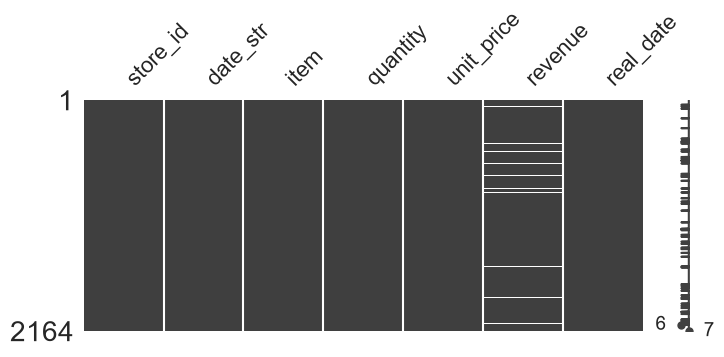

In [56]:
bakery['real_date']=pd.to_datetime(bakery["date_str"], format="mixed", errors="coerce")
bakery_sort=bakery.sort_values('real_date')
msno.matrix(bakery_sort, figsize=(8, 3)); plt.show()

그냥 str이었던 date_str을 날짜형으로 바꾼 뒤, 시간 순서대로 정렬하고 matrix를 그려보았는데 -> 결측치와 시간은 관련이 없는 것 처럼 보인다

In [57]:
missing_revenue=bakery[bakery['revenue'].isna()]
print(missing_revenue.head(3))

    store_id    date_str  item  quantity  unit_price  revenue  real_date
13       S02  2025-04-01  샌드위치         3       12000      NaN 2025-04-01
169      S02    20250515    식빵         2        4500      NaN 2025-05-15
201      S04  2025-04-01   케이크         1        5500      NaN 2025-04-01


결측치가 있는 행만 가져온 뒤, 매장 또는 날짜와 관련이 있는지도 살펴보고자 한다

In [58]:
print("=== 매장별 결측 개수 ===")
print(missing_revenue["store_id"].str.strip().value_counts())
print("\n=== 날짜별 결측 개수 (상위 10) ===")
print(missing_revenue["real_date"].value_counts())

=== 매장별 결측 개수 ===
store_id
S01    13
S05    12
S02     9
S04     9
S03     9
S06     8
Name: count, dtype: int64

=== 날짜별 결측 개수 (상위 10) ===
real_date
2025-06-20    22
2025-04-01    19
2025-05-15    19
Name: count, dtype: int64


매장별 결측 개수, 날짜별 결측 개수를 봐도 그 숫자의 차이가 유의해보이지 않기 때문에 최종적으로 revenue에서의 결측은 무작위(MCAR)로 판단하고 추후 정제 과정에서 제거하기로 결정하고자 한다

In [59]:
bakery = bakery.drop('real_date', axis=1)

뒤에서 date_str을 다시 날짜형으로 바꾸는 걸 한번에 코드로 작성할거기 때문에 혼란을 피하고자 만들었던 real_date컬럼은 삭제한다

In [60]:
# 시나리오 2 — 모범 답안
def b_dedup(df): return df.drop_duplicates().reset_index(drop=True)
def b_strip_store(df): return df.assign(store_id=df["store_id"].str.strip())
def b_unify_item(df): return df.assign(item=df["item"].replace({"케익": "케이크"}))
def b_parse_date(df): return df.assign(
    date=pd.to_datetime(df["date_str"], format="mixed", errors="coerce")
).drop(columns=["date_str"])

refunds_bakery = bakery[bakery["revenue"] < 0].copy()

bakery_clean = (
    bakery
    .pipe(b_dedup)
    .pipe(b_strip_store)
    .pipe(b_unify_item)
    .pipe(b_parse_date)
    .pipe(lambda d: d[d["revenue"] >= 0])    # 환불 분리 후 본 분석에서 제외
    .pipe(lambda d: d.dropna(subset=["revenue"]))
    .reset_index(drop=True)
)

print(f"정제 전: {bakery.shape}  →  정제 후: {bakery_clean.shape}")
print(f"환불 보관: {len(refunds_bakery)}건")
print(f"item 종류: {bakery_clean['item'].unique()}")

정제 전: (2164, 6)  →  정제 후: (1784, 6)
환불 보관: 1건
item 종류: <ArrowStringArray>
['쿠키', '케이크', '샌드위치', '크루아상', '식빵']
Length: 5, dtype: str


중복제거, 공백제거, 표기혼재 해결, 날짜형바꾸기 등으로 정제를 하고나니 행이 2164에서 1784로 줄어들었다. 그리고 revenue에 음수값이 하나 있었는데, 이는 refund자료로 넘기고, 우리가 할 분석에서는 제외하고자 한다

In [61]:
print(bakery_clean)

     store_id  item  quantity  unit_price   revenue       date
0         S01    쿠키         2       12000   24000.0 2025-04-01
1         S02   케이크         2       12000   24000.0 2025-04-01
2         S03    쿠키         1        5500    5500.0 2025-04-01
3         S04    쿠키         2        8500   17000.0 2025-06-20
4         S05  샌드위치         5        4500   22500.0 2025-04-01
...       ...   ...       ...         ...       ...        ...
1779      S05   케이크         2       12000   24000.0 2025-04-01
1780      S06    쿠키        50        5500  275000.0 2025-06-20
1781      S02    식빵         1        4500    4500.0 2025-05-15
1782      S03  샌드위치         2        3500    7000.0 2025-04-01
1783      S04    식빵        50        5500  275000.0 2025-05-15

[1784 rows x 6 columns]


최종적으로 정제한 데이터는 위와 같이 생겼다

In [62]:
# 시나리오 3 — 모범 답안

# KPI 1: 월별·매장별 매출 합계 (wide)
bakery_clean["month"] = bakery_clean["date"].dt.to_period("M").astype(str)
store_month = (
    bakery_clean.groupby(["store_id", "month"])["revenue"].sum().unstack(fill_value=0).round(0)
)
print("월별·매장별 매출:")
display(store_month)

# KPI 2: 상품별 평균 단가·총매출
item_kpi = (
    bakery_clean.groupby("item")
    .agg(avg_price=("unit_price", "mean"), total_revenue=("revenue", "sum"), n_orders=("revenue", "count"))
    .round(0)
    .sort_values("total_revenue", ascending=False)
)
print("\n상품별 KPI:")
display(item_kpi)

# Parquet 저장
store_month.to_parquet(OUT_DIR / "bakery_store_month.parquet")
item_kpi.to_parquet(OUT_DIR / "bakery_item_kpi.parquet")
print(f"\nParquet 저장 완료: {OUT_DIR.resolve()}")


월별·매장별 매출:


month,2025-04,2025-05,2025-06
store_id,,,
S01,6834000.0,7243500.0,5884000.0
S02,7531500.0,6768500.0,7996500.0
S03,7424500.0,4548000.0,7297500.0
S04,6471500.0,7105000.0,6744500.0
S05,8681500.0,4102000.0,4960000.0
S06,9156000.0,5095500.0,6796500.0



상품별 KPI:


,avg_price,total_revenue,n_orders
item,,,
쿠키,6878.0,26690000.0,365
샌드위치,6555.0,26297000.0,370
케이크,6859.0,23788500.0,359
식빵,6555.0,22997500.0,355
크루아상,6946.0,20867500.0,335



Parquet 저장 완료: C:\Users\JEON YUNA\my-first\ai-data-bootcamp\D009\d009_outputs


매출에 대해서는 S06 store, 2025-04의 경우에 가장 높았고, 상품별 KPI를 확인해보니 가장 매출을 높이는데 관여한 item은 쿠키라는 것을 알 수 있었다. 간단하게 월별/매장별 매출은 heatmap으로, 상품별KPI는 막대그래프로 시각화해보고자한다

In [63]:
plt.rcParams["font.family"] = "Malgun Gothic" 

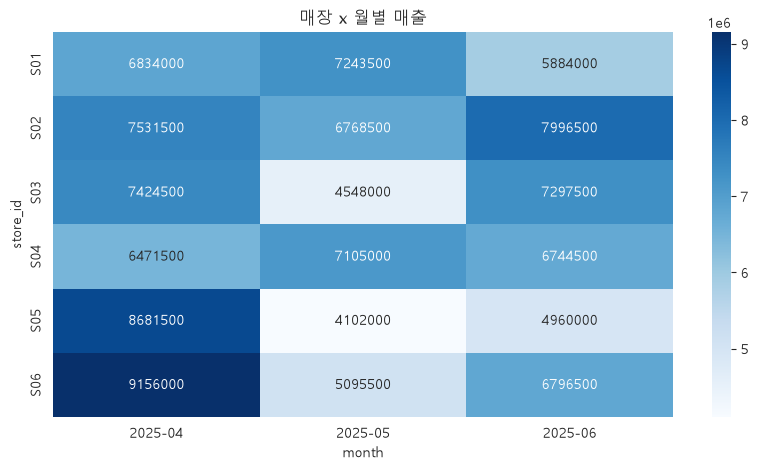

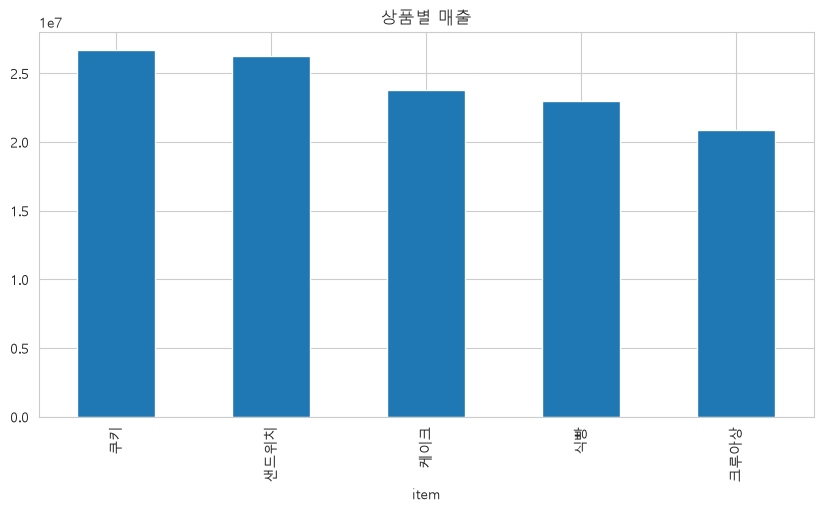

In [64]:
# 1. 매장 x 월별 매출 히트맵
sns.heatmap(store_month, annot=True, fmt=".0f", cmap="Blues")
plt.title("매장 x 월별 매출")
plt.show()

# 2. 상품별 매출 막대그래프
item_kpi["total_revenue"].sort_values(ascending=False).plot(kind="bar")
plt.title("상품별 매출")
plt.show()

In [66]:
#  S06의 2025-04 매출을 견인한 상품 확인

# 날짜에서 월 추출 (아직 안 했다면 이 줄 필요)
bakery_clean["month"] = bakery_clean["date"].dt.to_period("M").astype(str)

# S06 + 2025-04만 필터링
s06_april = bakery_clean[
    (bakery_clean["store_id"] == "S06") & (bakery_clean["month"] == "2025-04")
]

# 그 안에서 상품별 매출 합계, 내림차순 정렬
print("\n=== S06, 2025-04 상품별 매출 ===")
print(s06_april.groupby("item")["revenue"].sum().sort_values(ascending=False))



=== S06, 2025-04 상품별 매출 ===
item
샌드위치    3815500.0
식빵      2338500.0
쿠키      1676000.0
케이크      679000.0
크루아상     647000.0
Name: revenue, dtype: float64


S06의 25년도 4월이 매출이 가장 높았다고 하는데, 왜 매출이 높았을지를 분석해보고자 했다. 분석결과 25년도 4월에는 샌드위치가 매출에 가장 큰 영향을 준 것으로 보인다. 전체적으로 봤을 때에는 쿠키가 제일 잘 팔리는 것 같은데 이때는 왜 샌드위치가 더 잘 팔렸는지도 분석해보면 좋을 것 같다. 